In [ ]:
!git clone https://github.com/exEKS/python_SaaS.git

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ── 1. Завантаження та сортування ──────────────────────────────
df = pd.read_csv("/content/drive/MyDrive/csv/the_last_one.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print('Shape:', df.shape)
df.head()

Shape: (26448, 65)


,date,alarm_count,alarm_total_duration_min,alarm_all_region,city_address,day_tempmax,day_tempmin,day_temp,day_humidity,day_windspeed,...,weather_Snow_Freezing_Drizzle/Freezing_Rain_Overcast,weather_Snow_Freezing_Drizzle/Freezing_Rain_Partially_cloudy,weather_Snow_Overcast,weather_Snow_Partially_cloudy,weather_Snow_Rain,weather_Snow_Rain_Freezing_Drizzle/Freezing_Rain_Overcast,weather_Snow_Rain_Freezing_Drizzle/Freezing_Rain_Partially_cloudy,weather_Snow_Rain_Ice_Overcast,weather_Snow_Rain_Overcast,weather_Snow_Rain_Partially_cloudy
0,2022-02-24,0.0,0.0,0.0,"Ivano-Frankivsk,Ukraine",5.7,0.1,2.7,75.2,15.1,...,False,False,False,False,False,False,False,False,False,True
1,2022-02-24,0.0,0.0,0.0,"Chernivtsi,Ukraine",6.5,-0.2,3.4,74.9,17.9,...,False,False,False,True,False,False,False,False,False,False
2,2022-02-24,1.0,30.0,1.0,"Vinnytsia,Ukraine",5.0,0.7,2.8,80.5,10.8,...,False,False,False,False,False,False,False,False,False,True
3,2022-02-24,0.0,0.0,0.0,"Cherkasy,Ukraine",4.9,-0.1,1.9,83.4,8.3,...,False,False,False,False,False,False,False,False,False,False
4,2022-02-24,0.0,0.0,0.0,"Dnipro,Ukraine",8.0,-2.0,3.1,70.6,21.6,...,False,False,False,False,False,False,False,False,False,False


In [4]:
# ── 2. Визначення X та y ───────────────────────────────────────
TARGET = 'alarm_all_region'

LEAKAGE_COLS = [
    'alarm_count',
    'alarm_total_duration_min',
    'target_alarm_next_day',
]

# Включаємо числові + булеві (weather_* колонки)
X = (df
     .select_dtypes(include=[np.number, bool])
     .drop(columns=[TARGET] + LEAKAGE_COLS, errors='ignore')
     .fillna(0)
     .astype(float))  # XGBoost хоче float, не bool

y = df[TARGET].astype(int)

feature_cols = X.columns.tolist()
print(f' Фічі ({len(feature_cols)}): {feature_cols}')
print(f'\nTarget розподіл:\n{y.value_counts()}')

 Фічі (55): ['day_tempmax', 'day_tempmin', 'day_temp', 'day_humidity', 'day_windspeed', 'reddit_post_count', 'reddit_avg_score', 'text_intensity_index', 'alarm_lag1', 'alarm_lag2', 'alarm_roll7_mean', 'duration_lag1', 'region_Івано_Франківська_обл', 'region_Волинська_обл', 'region_Вінницька_обл', 'region_Дніпропетровська_обл', 'region_Донецька_обл', 'region_Житомирська_обл', 'region_Закарпатська_обл', 'region_Запорізька_обл', 'region_Київ', 'region_Київська_обл', 'region_Кіровоградська_обл', 'region_Львівська_обл', 'region_Миколаївська_обл', 'region_Одеська_обл', 'region_Полтавська_обл', 'region_Рівненська_обл', 'region_Сумська_обл', 'region_Тернопільська_обл', 'region_Харківська_обл', 'region_Херсонська_обл', 'region_Хмельницька_обл', 'region_Черкаська_обл', 'region_Чернівецька_обл', 'region_Чернігівська_обл', 'weather_Clear', 'weather_Overcast', 'weather_Partially_cloudy', 'weather_Rain', 'weather_Rain_Freezing_Drizzle/Freezing_Rain_Overcast', 'weather_Rain_Overcast', 'weather_Rain_P

In [5]:
# ── 3. TimeSeriesSplit ─────────────────────────────────────────
rows_per_day = df.groupby('date').size().mean()
test_size = int(rows_per_day * 30)
print(f'Рядків/день: {rows_per_day:.0f}  →  test_size={test_size}')

tscv = TimeSeriesSplit(
    n_splits=5,
    test_size=test_size,
    gap=0
)

Рядків/день: 24  →  test_size=720


In [6]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators":     [100, 200, 300],
    "max_depth":        [3, 4, 6, 8],
    "learning_rate":    [0.01, 0.05, 0.1, 0.2],
    "subsample":        [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
}

tscv_tune = TimeSeriesSplit(n_splits=3, test_size=test_size)

base_xgb = XGBClassifier(
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)

search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_grid,
    n_iter=20,
    cv=tscv_tune,
    scoring="f1_weighted",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X.values, y.values)

print("Найкращі параметри:")
print(search.best_params_)
print(f"Найкращий F1 (cv): {search.best_score_:.3f}")


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Найкращі параметри:
{'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Найкращий F1 (cv): 0.819


In [7]:
# ── 4. XGBoost — навчання по фолдах ───────────────────────────
xgb_clf = search.best_estimator_

acc_scores = []
f1_scores  = []
y_test_last = None
y_pred_last = None

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train = X.iloc[train_idx].values
    X_test  = X.iloc[test_idx].values
    y_train = y.iloc[train_idx].values
    y_test  = y.iloc[test_idx].values

    xgb_clf.fit(X_train, y_train)
    y_pred = xgb_clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    acc_scores.append(acc)
    f1_scores.append(f1)

    if fold == 4:
        y_test_last = y_test
        y_pred_last = y_pred

    print(f"Fold {fold+1} | train={len(train_idx):,}  test={len(test_idx):,} | acc={acc:.3f}  f1={f1:.3f}")

print()
print(f"Середнє  | acc={np.mean(acc_scores):.3f} +/-{np.std(acc_scores):.3f}  |  f1={np.mean(f1_scores):.3f} +/-{np.std(f1_scores):.3f}")


Fold 1 | train=22,848  test=720 | acc=0.828  f1=0.827
Fold 2 | train=23,568  test=720 | acc=0.840  f1=0.840
Fold 3 | train=24,288  test=720 | acc=0.807  f1=0.801
Fold 4 | train=25,008  test=720 | acc=0.808  f1=0.807
Fold 5 | train=25,728  test=720 | acc=0.851  f1=0.850

Середнє  | acc=0.827 +/-0.017  |  f1=0.825 +/-0.019


In [8]:
# ── 5. Confusion matrix (fold 5 — найсвіжіші дані) ────────────
print('Confusion matrix (fold 5):')
print(confusion_matrix(y_test_last, y_pred_last))
print()
print(classification_report(y_test_last, y_pred_last, zero_division=0))

Confusion matrix (fold 5):
[[163  60]
 [ 47 450]]

              precision    recall  f1-score   support

           0       0.78      0.73      0.75       223
           1       0.88      0.91      0.89       497

    accuracy                           0.85       720
   macro avg       0.83      0.82      0.82       720
weighted avg       0.85      0.85      0.85       720



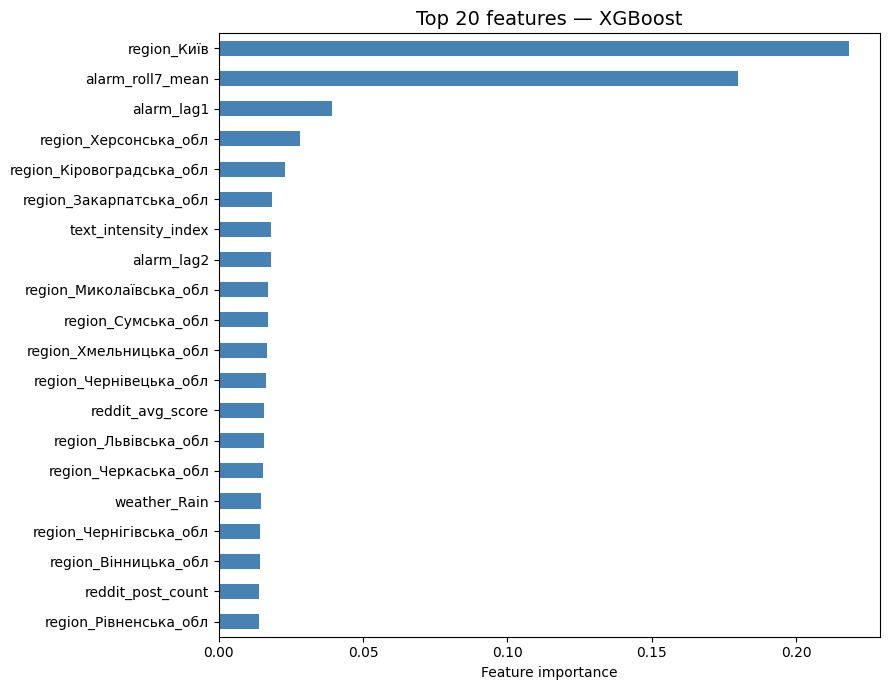

In [9]:
# ── 6. Top-20 feature importance ──────────────────────────────
importances = pd.Series(xgb_clf.feature_importances_, index=feature_cols)
top20 = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
top20.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 features — XGBoost', fontsize=14)
ax.set_xlabel('Feature importance')
plt.tight_layout()
plt.show()